
<div style="border-radius:10px;
            border : #015a2c solid;
            background-color:#D7D9DB;
           font-size:110%;
           letter-spacing:0.5px;
            text-align: center">
​
<center><h1 style="padding: 25px 0px; color:#015a4c; font-weight: bold; font-family: Cursive">
Amit Project for Data Science Module <br><br>💡💡💡💡💡 <br><br> DEPI_BS_DS_R3  </h1></center>
<center><h3 style="padding-bottom: 25px; color:#025b2c; font-weight: bold; font-style:italic; font-family: Cursive">
Using Project: Trip data Ford go bike  </h3></center>     
​
</div>

# Part I - (Dataset Exploration for Ford GoBike)

### worked by (Omar Mohamed Fathy Dahi /2026 )

## Introduction

.

> **Let's introduce our dataset:**


======================================

.

**This data set information was produced from `Ford GoBike` System** the information in it talked about individual rides that were made in a bike-sharing system for covering San Francisco Bay area.** 

.




> ## And here are the main exploring questions 



   **==================================================**



- What is the structure of your dataset?


- What are the main interesting features in the dataset?


- What features in the dataset supported my investigation for these interesting features?




.

> ### Also here are the investigative questions classified into three types



   **================================================**
   
   


###  <a href='#011'> Univariate Exploration</a> 

- <a href='#1'> 1 ) . What is the distribution of `User type`?</a>  
- <a href='#2'> 2 ) . What is the distribution for the `bike share users on all Trips`?</a>  
- <a href='#3'> 3 ) . What is the distribution for users' `ages`?</a>  
- <a href='#4'> 4 ) . Do the users' ages have `outlier` values?</a>
- <a href='#5'> 5 ) . What is the distribution for the trip duration in `minutes`? </a>
- <a href='#6'> 6) . What is the distribution for `member_gender`? </a>
- <a href='#7'> 7) . What is the distribution for the trip duration in `Hours`?  </a>




##  <a href='#111'> Bivariate Exploration</a> 


- <a href='#8'> 8 ) . What the `average duration` of trip for the categories of `user type`? </a>
- <a href='#9'> 9 ) . How long is the duration of the trip for `each gender` in `minutes`? </a>
- <a href='#10'> 10 ) . How long is the duration of the trip for each `user_type` in `minutes`?  </a>
- <a href='#11'> 11 ) . How the user distribution depending on their `Age` and `user_type` ?</a>
- <a href='#12'>12 ). How the user distribution depending on their `Age` and `member_gender` ?  </a>


##  <a href='#1111'> Multivariate Exploration</a> 


- <a href='#13'> 13 ) . What is the Correlation between `each` variable in the dataset?</a>  
- <a href='#14'> 14 ) . What is the Correlation between `specific numeric variables` in the dataset?</a>  
- <a href='#15'> 15 ) . What is the  Correlation between `data_stat` variables in the dataset?</a>  


##  <a href='#1100'> Conclusions </a> 




# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Import Libraries</p>

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import matplotlib.pyplot as plt
import math
import seaborn as sns
%matplotlib inline

In [5]:
# Load my dataset using pandas Dataframe

df=pd.read_csv("fordgobike-tripdataFor201902.csv")
df_new=pd.read_csv("201902-fordgobike-tripdata.csv")

In [6]:
df_time=df_new[["start_time","end_time"]]
df_time["end_time"].dtype

<StringDtype(storage='python', na_value=nan)>

In [7]:
# here we make overview in high-level for data shape and composition

print("The shape of the dataset is: ", df.shape,'\n')
print("the columns of the dataset are: ", df.columns,'\n')
print("the diminsion of the dataset is: ",df.ndim)

The shape of the dataset is:  (183416, 16) 

the columns of the dataset are:  Index(['duration_sec', 'start_time', 'end_time', 'start_station_id',
       'start_station_name', 'start_station_latitude',
       'start_station_longitude', 'end_station_id', 'end_station_name',
       'end_station_latitude', 'end_station_longitude', 'bike_id', 'user_type',
       'member_birth_year', 'member_gender', 'bike_share_for_all_trip'],
      dtype='str') 

the diminsion of the dataset is:  2


In [8]:
## check each var  datatype 

print("the datatypes of the dataset are:\n", df.dtypes,'\n')
print("the datatypes of the dataset are:\n", df.dtypes.value_counts(),'\n')

dtype=df.dtypes
num_unique=df.nunique()
dect=pd.DataFrame({'dtype':dtype,'num_unique':num_unique}).T
print(dect)

the datatypes of the dataset are:
 duration_sec                 int64
start_time                     str
end_time                       str
start_station_id           float64
start_station_name             str
start_station_latitude     float64
start_station_longitude    float64
end_station_id             float64
end_station_name               str
end_station_latitude       float64
end_station_longitude      float64
bike_id                      int64
user_type                      str
member_birth_year          float64
member_gender                  str
bike_share_for_all_trip        str
dtype: object 

the datatypes of the dataset are:
 str        7
float64    7
int64      2
Name: count, dtype: int64 

           duration_sec start_time end_time start_station_id  \
dtype             int64        str      str          float64   
num_unique         4752      35783    35767              329   

           start_station_name start_station_latitude start_station_longitude  \
dtype         

In [9]:
## I display 15 rows to understand the content values more 
df.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,32:10.1,01:56.0,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,53:21.8,42:03.1,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,13:13.2,24:08.1,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,54:26.0,02:36.8,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,54:18.5,20:44.1,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes


In [10]:
# descriptive statistics for numeric variables
print("Descriptive statistics for numeric variables:\n", df.describe(),'\n')

Descriptive statistics for numeric variables:
         duration_sec  start_station_id  start_station_latitude  \
count  183416.000000     183219.000000           183416.000000   
mean      726.067311        138.590365               37.771221   
std      1794.371831        111.778938                0.099586   
min        61.000000          3.000000               37.317298   
25%       325.000000         47.000000               37.770083   
50%       514.000000        104.000000               37.780760   
75%       796.000000        239.000000               37.797280   
max     85444.000000        398.000000               37.880222   

       start_station_longitude  end_station_id  end_station_latitude  \
count            183416.000000   183219.000000         183416.000000   
mean               -122.352661      136.249401             37.771425   
std                   0.117100      111.514916              0.099494   
min                -122.453705        3.000000             37.317298  



> ### What is the structure of your dataset?





- The structure of the dataset contains  16 columns and 183416 rows.
 
 
- Most variables are str&float64 in nature , and here are **dtypes summary :**

        - str(7)
        - int(2)
        - float(7)
        



> ### What are the main interesting features in the dataset?




 **We got three main feature areas which are :**
 
 
 
 
- duration_sec
 
 
 
- bike_share_for_all_trip
 
  
 
  
- user_type




> ### What features in the dataset supported my investigation for these interesting features?



- bike_share_for_all_trip



- user_type



- member_gender


-member_birth_year




- duration_sec



##  More Exploring ideas to begin my investigation

In [11]:
#This code for describing statistical data ideas in a more organized and readable table

print("Descriptive statistics for numeric variables in a more organized and readable table:\n", df.describe().T,'\n')

Descriptive statistics for numeric variables in a more organized and readable table:
                             count         mean          std          min  \
duration_sec             183416.0   726.067311  1794.371831    61.000000   
start_station_id         183219.0   138.590365   111.778938     3.000000   
start_station_latitude   183416.0    37.771221     0.099586    37.317298   
start_station_longitude  183416.0  -122.352661     0.117100  -122.453705   
end_station_id           183219.0   136.249401   111.514916     3.000000   
end_station_latitude     183416.0    37.771425     0.099494    37.317298   
end_station_longitude    183416.0  -122.352247     0.116677  -122.453705   
bike_id                  183416.0  4472.890260  1664.386068    11.000000   
member_birth_year        175151.0  1984.806504    10.116589  1878.000000   

                                 25%          50%          75%           max  
duration_sec              325.000000   514.000000   796.000000  85444.0000

In [12]:
# display the information about each column

print("Information about each column:\n", df.info(),'\n')
print("the member birth year contains null vales:\n", df['member_birth_year'].isnull().sum(),'\n')

<class 'pandas.DataFrame'>
RangeIndex: 183416 entries, 0 to 183415
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183416 non-null  int64  
 1   start_time               183416 non-null  str    
 2   end_time                 183416 non-null  str    
 3   start_station_id         183219 non-null  float64
 4   start_station_name       183219 non-null  str    
 5   start_station_latitude   183416 non-null  float64
 6   start_station_longitude  183416 non-null  float64
 7   end_station_id           183219 non-null  float64
 8   end_station_name         183219 non-null  str    
 9   end_station_latitude     183416 non-null  float64
 10  end_station_longitude    183416 non-null  float64
 11  bike_id                  183416 non-null  int64  
 12  user_type                183416 non-null  str    
 13  member_birth_year        175151 non-null  float64
 14  member_gender  

## <mark>The above result show some missing values exist in some columns So let's display them </mark>

In [13]:
#yOUR CODES
print("the number of null values in each column:\n", df.isnull().sum(),'\n')




the number of null values in each column:
 duration_sec                  0
start_time                    0
end_time                      0
start_station_id            197
start_station_name          197
start_station_latitude        0
start_station_longitude       0
end_station_id              197
end_station_name            197
end_station_latitude          0
end_station_longitude         0
bike_id                       0
user_type                     0
member_birth_year          8265
member_gender              8265
bike_share_for_all_trip       0
dtype: int64 





> ## <mark>The result above shows many missing data </mark>



###  To fix this issue You will fill these values with main or median for numeric and mode for categorical

In [14]:
df["start_time"]=df_time["start_time"].copy()
df["end_time"]=df_time["end_time"].copy()
df.dropna(subset=["start_time","end_time"],axis=0,inplace=True)

df['start_time'] = pd.to_datetime(df['start_time'].astype(str))
df['end_time'] = pd.to_datetime(df['end_time'].astype(str))

#mask = df['end_time'] < df['start_time']
#df.loc[mask, 'end_time'] += pd.Timedelta(days=1)

df['duration_sec'] = (df['end_time'] - df['start_time']).dt.total_seconds()
df['duration_minute'] = df['duration_sec'] / 60

df['date'] = df['start_time'].dt.date
df['hour'] = df['start_time'].dt.hour
df['day'] = df['start_time'].dt.day
df['day_of_week'] = df['start_time'].dt.day_name()
df["weekend"] = df["day_of_week"].isin(["Saturday", "Sunday"]).map({True: "Yes", False: "No"})
df['month'] = df['start_time'].dt.month
df['year'] = df['start_time'].dt.year

df['time_id'] = df['start_time'].dt.strftime('%Y%m%d%H')

In [15]:
dtype=df.dtypes
num_unique=df.nunique()
dect=pd.DataFrame({'dtype':dtype,'num_unique':num_unique}).T
dect

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,...,bike_share_for_all_trip,duration_minute,date,hour,day,day_of_week,weekend,month,year,time_id
dtype,float64,datetime64[us],datetime64[us],float64,str,float64,float64,float64,str,float64,...,str,float64,object,int32,int32,str,str,int32,int32,str
num_unique,168956,183401,183397,329,329,334,335,329,329,335,...,2,168956,28,24,28,7,2,1,1,672


In [16]:

print(df.columns)
df

Index(['duration_sec', 'start_time', 'end_time', 'start_station_id',
       'start_station_name', 'start_station_latitude',
       'start_station_longitude', 'end_station_id', 'end_station_name',
       'end_station_latitude', 'end_station_longitude', 'bike_id', 'user_type',
       'member_birth_year', 'member_gender', 'bike_share_for_all_trip',
       'duration_minute', 'date', 'hour', 'day', 'day_of_week', 'weekend',
       'month', 'year', 'time_id'],
      dtype='str')


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,...,bike_share_for_all_trip,duration_minute,date,hour,day,day_of_week,weekend,month,year,time_id
0,52185.830,2019-02-28 17:32:10.145,2019-03-01 08:01:55.975,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,...,No,869.763833,2019-02-28,17,28,Thursday,No,2,2019,2019022817
1,42521.267,2019-02-28 18:53:21.789,2019-03-01 06:42:03.056,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,...,No,708.687783,2019-02-28,18,28,Thursday,No,2,2019,2019022818
2,61854.928,2019-02-28 12:13:13.218,2019-03-01 05:24:08.146,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,...,No,1030.915467,2019-02-28,12,28,Thursday,No,2,2019,2019022812
3,36490.832,2019-02-28 17:54:26.010,2019-03-01 04:02:36.842,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,...,No,608.180533,2019-02-28,17,28,Thursday,No,2,2019,2019022817
4,1585.525,2019-02-28 23:54:18.549,2019-03-01 00:20:44.074,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,...,Yes,26.425417,2019-02-28,23,28,Thursday,No,2,2019,2019022823
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183407,480.310,2019-02-01 00:04:49.724,2019-02-01 00:12:50.034,27.0,Beale St at Harrison St,37.788059,-122.391865,324.0,Union Square (Powell St at Post St),37.788300,...,No,8.005167,2019-02-01,0,1,Friday,No,2,2019,2019020100
183408,313.758,2019-02-01 00:05:34.744,2019-02-01 00:10:48.502,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,66.0,3rd St at Townsend St,37.778742,...,No,5.229300,2019-02-01,0,1,Friday,No,2,2019,2019020100
183409,141.671,2019-02-01 00:06:05.549,2019-02-01 00:08:27.220,278.0,The Alameda at Bush St,37.331932,-121.904888,277.0,Morrison Ave at Julian St,37.333658,...,Yes,2.361183,2019-02-01,0,1,Friday,No,2,2019,2019020100
183410,139.927,2019-02-01 00:05:34.360,2019-02-01 00:07:54.287,220.0,San Pablo Ave at MLK Jr Way,37.811351,-122.273422,216.0,San Pablo Ave at 27th St,37.817827,...,No,2.332117,2019-02-01,0,1,Friday,No,2,2019,2019020100


In [17]:
df["users' age"] = df['start_time'].dt.year - df['member_birth_year']
df["users' age"] = df["users' age"].clip(upper=90)

bins = [0, 35, 55, 100]
labels = ['Young', 'Adult', 'Senior']

df['age_group'] = pd.cut(
    df["users' age"], bins=bins, labels=labels, right=True)

cat_cols = [
    'user_type',              
    'member_gender',          
    'bike_share_for_all_trip',
    'day_of_week',            
    'start_station_name',
    'end_station_name',
    'bike_id',
    'end_station_id',
    'start_station_id',
    'time_id',
    'age_group'
]


for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

num_cols = [
    'duration_sec',
    'duration_minute',
    "users' age",              
    'start_station_latitude',
    'start_station_longitude',
    'end_station_latitude',
    'end_station_longitude',    
    'hour',
    'day',
    'month',
    'year'
]

for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("Categorical Columns:", df.select_dtypes(include=['category', 'object']).columns.tolist())
print("Numerical Columns:", df.select_dtypes(include=['number']).columns.tolist())

Categorical Columns: ['start_station_id', 'start_station_name', 'end_station_id', 'end_station_name', 'bike_id', 'user_type', 'member_gender', 'bike_share_for_all_trip', 'date', 'day_of_week', 'weekend', 'time_id', 'age_group']
Numerical Columns: ['duration_sec', 'start_station_latitude', 'start_station_longitude', 'end_station_latitude', 'end_station_longitude', 'member_birth_year', 'duration_minute', 'hour', 'day', 'month', 'year', "users' age"]


C:\Users\Abanoub Maher\AppData\Local\Temp\ipykernel_37224\3639521700.py:47: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print("Categorical Columns:", df.select_dtypes(include=['category', 'object']).columns.tolist())


In [18]:
dtype=df.dtypes
num_unique=df.nunique()
dect=pd.DataFrame({'dtype':dtype,'num_unique':num_unique}).T
print(dect)

           duration_sec      start_time        end_time start_station_id  \
dtype           float64  datetime64[us]  datetime64[us]         category   
num_unique       168956          183401          183397              329   

           start_station_name start_station_latitude start_station_longitude  \
dtype                category                float64                 float64   
num_unique                329                    334                     335   

           end_station_id end_station_name end_station_latitude  ...    date  \
dtype            category         category              float64  ...  object   
num_unique            329              329                  335  ...      28   

             hour    day day_of_week weekend  month   year   time_id  \
dtype       int32  int32    category     str  int32  int32  category   
num_unique     24     28           7       2      1      1       672   

           users' age age_group  
dtype         float64  category  
num_

In [19]:
null=df.isna().sum()
ratio=((null/df.shape[0])*100).round(3)
dtype=df.dtypes
pd.DataFrame({"dtype":dtype,"null":null , "ratio(%)":ratio}).T
print(ratio)

duration_sec               0.000
start_time                 0.000
end_time                   0.000
start_station_id           0.107
start_station_name         0.107
start_station_latitude     0.000
start_station_longitude    0.000
end_station_id             0.107
end_station_name           0.107
end_station_latitude       0.000
end_station_longitude      0.000
bike_id                    0.000
user_type                  0.000
member_birth_year          4.506
member_gender              4.506
bike_share_for_all_trip    0.000
duration_minute            0.000
date                       0.000
hour                       0.000
day                        0.000
day_of_week                0.000
weekend                    0.000
month                      0.000
year                       0.000
time_id                    0.000
users' age                 4.506
age_group                  4.506
dtype: float64


In [20]:
cols_to_drop=["start_station_id","start_station_name","end_station_id","end_station_name"]
df.dropna(subset=cols_to_drop,axis=0,inplace=True)

In [21]:
null=df.isna().sum()
ratio=((null/df.shape[0])*100).round(3)
dtype=df.dtypes
pd.DataFrame({"dtype":dtype,"null":null , "ratio(%)":ratio}).T

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,...,date,hour,day,day_of_week,weekend,month,year,time_id,users' age,age_group
dtype,float64,datetime64[us],datetime64[us],category,category,float64,float64,category,category,float64,...,object,int32,int32,category,str,int32,int32,category,float64,category
null,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,8263,8263
ratio(%),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.51,4.51


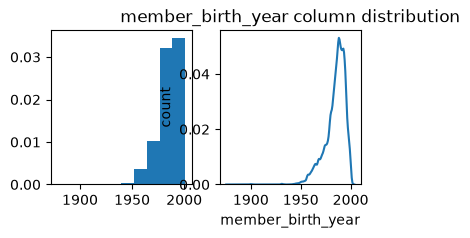

In [22]:
plt.figure(figsize=(4,2))
plt.subplot(1,2,1)
plt.hist(df["member_birth_year"],density=True)
plt.subplot(1,2,2)
sns.kdeplot(df["member_birth_year"])
plt.title("member_birth_year column distribution")
plt.xlabel("member_birth_year")
plt.ylabel("count")
plt.show()

In [23]:
df["member_gender"]=df["member_gender"].fillna(value='Other')
df["member_birth_year"]=df["member_birth_year"].fillna(value=df['member_birth_year'].median())

In [24]:
df["users' age"] = df['start_time'].dt.year - df['member_birth_year']
df["users' age"] = df["users' age"].clip(upper=90)

In [25]:
bins = [0, 35, 55, 100]
labels = ['Young', 'Adult', 'Senior']

df['age_group'] = pd.cut(
    df["users' age"], bins=bins, labels=labels, right=True)

In [26]:
#check the Nulls 
null=df.isna().sum()
ratio=((null/df.shape[0])*100).round(3)
dtype=df.dtypes
pd.DataFrame({"dtype":dtype,"null":null , "ratio(%)":ratio}).T
print(ratio)

duration_sec               0.0
start_time                 0.0
end_time                   0.0
start_station_id           0.0
start_station_name         0.0
start_station_latitude     0.0
start_station_longitude    0.0
end_station_id             0.0
end_station_name           0.0
end_station_latitude       0.0
end_station_longitude      0.0
bike_id                    0.0
user_type                  0.0
member_birth_year          0.0
member_gender              0.0
bike_share_for_all_trip    0.0
duration_minute            0.0
date                       0.0
hour                       0.0
day                        0.0
day_of_week                0.0
weekend                    0.0
month                      0.0
year                       0.0
time_id                    0.0
users' age                 0.0
age_group                  0.0
dtype: float64


### **And with a proper category for other (member gender)**

In [27]:
##  still got a missing value in the member_gender, so let's explore this column more 

print(df.member_gender.head(15))

0       Male
1      Other
2       Male
3      Other
4       Male
5       Male
6     Female
7       Male
8      Other
9       Male
10    Female
11      Male
12      Male
13     Other
14      Male
Name: member_gender, dtype: category
Categories (3, str): ['Female', 'Male', 'Other']


In [28]:
# fill  dataset with missing values.
    


In [29]:
# print(gbf.member_gender.head(15))

In [30]:
## check my result above 

#check the Nulls 
null=df.isna().sum()
ratio=((null/df.shape[0])*100).round(3)
dtype=df.dtypes
pd.DataFrame({"dtype":dtype,"null":null , "ratio(%)":ratio}).T

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,...,date,hour,day,day_of_week,weekend,month,year,time_id,users' age,age_group
dtype,float64,datetime64[us],datetime64[us],category,category,float64,float64,category,category,float64,...,object,int32,int32,category,str,int32,int32,category,float64,category
null,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ratio(%),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


> ## <mark>The result above shows that we deal with all missing data </mark>

### Now let's check duplicate value

In [31]:
# data clean up
df = df[df["duration_minute"] <= 120]

count = df[df["duration_minute"] > 120]["duration_minute"].count()
count/df['duration_minute'].count()

df = df[df["users' age"] <=75]

In [32]:
##  check duplicate in dataset

df.duplicated().sum()

np.int64(0)

In [33]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True)

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,...,date,hour,day,day_of_week,weekend,month,year,time_id,users' age,age_group
0,1585.525,2019-02-28 23:54:18.549,2019-03-01 00:20:44.074,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,...,2019-02-28,23,28,Thursday,No,2,2019,2019022823,45.0,Adult
1,1793.128,2019-02-28 23:49:58.632,2019-03-01 00:19:51.760,93.0,4th St at Mission Bay Blvd S,37.770407,-122.391198,323.0,Broadway at Kearny,37.798014,...,2019-02-28,23,28,Thursday,No,2,2019,2019022823,60.0,Senior
2,1147.484,2019-02-28 23:55:35.104,2019-03-01 00:14:42.588,300.0,Palm St at Willow St,37.317298,-121.884995,312.0,San Jose Diridon Station,37.329732,...,2019-02-28,23,28,Thursday,No,2,2019,2019022823,36.0,Adult
3,1615.990,2019-02-28 23:41:06.766,2019-03-01 00:08:02.756,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,...,2019-02-28,23,28,Thursday,No,2,2019,2019022823,30.0,Young
4,1570.925,2019-02-28 23:41:48.790,2019-03-01 00:07:59.715,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,...,2019-02-28,23,28,Thursday,No,2,2019,2019022823,31.0,Young
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182236,480.310,2019-02-01 00:04:49.724,2019-02-01 00:12:50.034,27.0,Beale St at Harrison St,37.788059,-122.391865,324.0,Union Square (Powell St at Post St),37.788300,...,2019-02-01,0,1,Friday,No,2,2019,2019020100,23.0,Young
182237,313.758,2019-02-01 00:05:34.744,2019-02-01 00:10:48.502,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,66.0,3rd St at Townsend St,37.778742,...,2019-02-01,0,1,Friday,No,2,2019,2019020100,35.0,Young
182238,141.671,2019-02-01 00:06:05.549,2019-02-01 00:08:27.220,278.0,The Alameda at Bush St,37.331932,-121.904888,277.0,Morrison Ave at Julian St,37.333658,...,2019-02-01,0,1,Friday,No,2,2019,2019020100,29.0,Young
182239,139.927,2019-02-01 00:05:34.360,2019-02-01 00:07:54.287,220.0,San Pablo Ave at MLK Jr Way,37.811351,-122.273422,216.0,San Pablo Ave at 27th St,37.817827,...,2019-02-01,0,1,Friday,No,2,2019,2019020100,31.0,Young


In [34]:
df.duplicated().sum()

np.int64(0)

> ##If Not significant duplicated , so won't clean it 


### Now let's check the category columns to make more cleaning dataset 

In [35]:
### check the category columns that included object
cate_cols=df.select_dtypes("category").columns
print(cate_cols)

Index(['start_station_id', 'start_station_name', 'end_station_id',
       'end_station_name', 'bike_id', 'user_type', 'member_gender',
       'bike_share_for_all_trip', 'day_of_week', 'time_id', 'age_group'],
      dtype='str')


 > ## From all previous results above I found  :
 
 
 
 **=========================================================**
 
 

> 1 ) **unique Value** as in ((`member_gender`)) : Not significant , so won't clean it



> 2 ) **Incorrect data type** as in (( `user_type` &&	`member_gender`)) :  significant change , so I need to clean it.


> 3 ) **Good factor** for marketing work as in ((`member_birth_year`)) : so I need to clean it.

In [36]:
##  step  2 ) Incorrect data type as in (( `user_type` &&	`member_gender`)) :  significant change , so  need to clean it.



In [37]:
## check your work 



In [38]:
df["users' age"].dtype

dtype('float64')

In [39]:
## check your work 

df.head(10)

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,...,date,hour,day,day_of_week,weekend,month,year,time_id,users' age,age_group
4,1585.525,2019-02-28 23:54:18.549,2019-03-01 00:20:44.074,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,...,2019-02-28,23,28,Thursday,No,2,2019,2019022823,45.0,Adult
5,1793.128,2019-02-28 23:49:58.632,2019-03-01 00:19:51.760,93.0,4th St at Mission Bay Blvd S,37.770407,-122.391198,323.0,Broadway at Kearny,37.798014,...,2019-02-28,23,28,Thursday,No,2,2019,2019022823,60.0,Senior
6,1147.484,2019-02-28 23:55:35.104,2019-03-01 00:14:42.588,300.0,Palm St at Willow St,37.317298,-121.884995,312.0,San Jose Diridon Station,37.329732,...,2019-02-28,23,28,Thursday,No,2,2019,2019022823,36.0,Adult
7,1615.990,2019-02-28 23:41:06.766,2019-03-01 00:08:02.756,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,...,2019-02-28,23,28,Thursday,No,2,2019,2019022823,30.0,Young
8,1570.925,2019-02-28 23:41:48.790,2019-03-01 00:07:59.715,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,...,2019-02-28,23,28,Thursday,No,2,2019,2019022823,31.0,Young
9,1049.326,2019-02-28 23:49:47.699,2019-03-01 00:07:17.025,19.0,Post St at Kearny St,37.788975,-122.403452,121.0,Mission Playground,37.759210,...,2019-02-28,23,28,Thursday,No,2,2019,2019022823,27.0,Young
10,458.224,2019-02-28 23:57:57.211,2019-03-01 00:05:35.435,370.0,Jones St at Post St,37.787327,-122.413278,43.0,San Francisco Public Library (Grove St at Hyde...,37.778768,...,2019-02-28,23,28,Thursday,No,2,2019,2019022823,23.0,Young
11,506.193,2019-02-28 23:56:55.540,2019-03-01 00:05:21.733,44.0,Civic Center/UN Plaza BART Station (Market St ...,37.781074,-122.411738,343.0,Bryant St at 2nd St,37.783172,...,2019-02-28,23,28,Thursday,No,2,2019,2019022823,26.0,Young
12,1176.533,2019-02-28 23:45:12.651,2019-03-01 00:04:49.184,127.0,Valencia St at 21st St,37.756708,-122.421025,323.0,Broadway at Kearny,37.798014,...,2019-02-28,23,28,Thursday,No,2,2019,2019022823,29.0,Young
13,915.805,2019-02-28 23:49:06.062,2019-03-01 00:04:21.867,252.0,Channing Way at Shattuck Ave,37.865847,-122.267443,244.0,Shattuck Ave at Hearst Ave,37.873676,...,2019-02-28,23,28,Thursday,No,2,2019,2019022823,32.0,Young


In [40]:
## change the new column age data type from float to int
df["users' age"].dtype



dtype('float64')

In [41]:
## create a function to know the average users ages

def avg(df:pd.DataFrame,col:str)->float:
    """Calculates the arithmetic mean of a specified numerical column in a
  pandas DataFrame.

  Args:
      df (pd.DataFrame): The DataFrame containing the target dataset.
      col (str): The name of the numerical column to calculate the mean for.

  Returns:
      float: The calculated mean of the specified column, ignoring missing
        (NaN) values.
  """

    return float(df[col].mean().__round__(4))

In [42]:
avg_age=avg(df,"users' age")
print(avg_age)

34.0114


In [43]:
## another important factor to offer  marketing services is the trip duration time 

## need to change the time from second to minute to be more usable

df.head(10)
#df["duration_minute"]=df['duration_sec']/60

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,...,date,hour,day,day_of_week,weekend,month,year,time_id,users' age,age_group
4,1585.525,2019-02-28 23:54:18.549,2019-03-01 00:20:44.074,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,...,2019-02-28,23,28,Thursday,No,2,2019,2019022823,45.0,Adult
5,1793.128,2019-02-28 23:49:58.632,2019-03-01 00:19:51.760,93.0,4th St at Mission Bay Blvd S,37.770407,-122.391198,323.0,Broadway at Kearny,37.798014,...,2019-02-28,23,28,Thursday,No,2,2019,2019022823,60.0,Senior
6,1147.484,2019-02-28 23:55:35.104,2019-03-01 00:14:42.588,300.0,Palm St at Willow St,37.317298,-121.884995,312.0,San Jose Diridon Station,37.329732,...,2019-02-28,23,28,Thursday,No,2,2019,2019022823,36.0,Adult
7,1615.990,2019-02-28 23:41:06.766,2019-03-01 00:08:02.756,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,...,2019-02-28,23,28,Thursday,No,2,2019,2019022823,30.0,Young
8,1570.925,2019-02-28 23:41:48.790,2019-03-01 00:07:59.715,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,...,2019-02-28,23,28,Thursday,No,2,2019,2019022823,31.0,Young
9,1049.326,2019-02-28 23:49:47.699,2019-03-01 00:07:17.025,19.0,Post St at Kearny St,37.788975,-122.403452,121.0,Mission Playground,37.759210,...,2019-02-28,23,28,Thursday,No,2,2019,2019022823,27.0,Young
10,458.224,2019-02-28 23:57:57.211,2019-03-01 00:05:35.435,370.0,Jones St at Post St,37.787327,-122.413278,43.0,San Francisco Public Library (Grove St at Hyde...,37.778768,...,2019-02-28,23,28,Thursday,No,2,2019,2019022823,23.0,Young
11,506.193,2019-02-28 23:56:55.540,2019-03-01 00:05:21.733,44.0,Civic Center/UN Plaza BART Station (Market St ...,37.781074,-122.411738,343.0,Bryant St at 2nd St,37.783172,...,2019-02-28,23,28,Thursday,No,2,2019,2019022823,26.0,Young
12,1176.533,2019-02-28 23:45:12.651,2019-03-01 00:04:49.184,127.0,Valencia St at 21st St,37.756708,-122.421025,323.0,Broadway at Kearny,37.798014,...,2019-02-28,23,28,Thursday,No,2,2019,2019022823,29.0,Young
13,915.805,2019-02-28 23:49:06.062,2019-03-01 00:04:21.867,252.0,Channing Way at Shattuck Ave,37.865847,-122.267443,244.0,Shattuck Ave at Hearst Ave,37.873676,...,2019-02-28,23,28,Thursday,No,2,2019,2019022823,32.0,Young


In [44]:
## I need to change the time from second to Houre  to be more usable

#df["duration_houre"]=df['duration_sec']/(60*60)

In [45]:
## check your work 
df.head(10)

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,...,date,hour,day,day_of_week,weekend,month,year,time_id,users' age,age_group
4,1585.525,2019-02-28 23:54:18.549,2019-03-01 00:20:44.074,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,...,2019-02-28,23,28,Thursday,No,2,2019,2019022823,45.0,Adult
5,1793.128,2019-02-28 23:49:58.632,2019-03-01 00:19:51.760,93.0,4th St at Mission Bay Blvd S,37.770407,-122.391198,323.0,Broadway at Kearny,37.798014,...,2019-02-28,23,28,Thursday,No,2,2019,2019022823,60.0,Senior
6,1147.484,2019-02-28 23:55:35.104,2019-03-01 00:14:42.588,300.0,Palm St at Willow St,37.317298,-121.884995,312.0,San Jose Diridon Station,37.329732,...,2019-02-28,23,28,Thursday,No,2,2019,2019022823,36.0,Adult
7,1615.990,2019-02-28 23:41:06.766,2019-03-01 00:08:02.756,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,...,2019-02-28,23,28,Thursday,No,2,2019,2019022823,30.0,Young
8,1570.925,2019-02-28 23:41:48.790,2019-03-01 00:07:59.715,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,...,2019-02-28,23,28,Thursday,No,2,2019,2019022823,31.0,Young
9,1049.326,2019-02-28 23:49:47.699,2019-03-01 00:07:17.025,19.0,Post St at Kearny St,37.788975,-122.403452,121.0,Mission Playground,37.759210,...,2019-02-28,23,28,Thursday,No,2,2019,2019022823,27.0,Young
10,458.224,2019-02-28 23:57:57.211,2019-03-01 00:05:35.435,370.0,Jones St at Post St,37.787327,-122.413278,43.0,San Francisco Public Library (Grove St at Hyde...,37.778768,...,2019-02-28,23,28,Thursday,No,2,2019,2019022823,23.0,Young
11,506.193,2019-02-28 23:56:55.540,2019-03-01 00:05:21.733,44.0,Civic Center/UN Plaza BART Station (Market St ...,37.781074,-122.411738,343.0,Bryant St at 2nd St,37.783172,...,2019-02-28,23,28,Thursday,No,2,2019,2019022823,26.0,Young
12,1176.533,2019-02-28 23:45:12.651,2019-03-01 00:04:49.184,127.0,Valencia St at 21st St,37.756708,-122.421025,323.0,Broadway at Kearny,37.798014,...,2019-02-28,23,28,Thursday,No,2,2019,2019022823,29.0,Young
13,915.805,2019-02-28 23:49:06.062,2019-03-01 00:04:21.867,252.0,Channing Way at Shattuck Ave,37.865847,-122.267443,244.0,Shattuck Ave at Hearst Ave,37.873676,...,2019-02-28,23,28,Thursday,No,2,2019,2019022823,32.0,Young


In [46]:
df['trip_id'] = range(1, len(df) + 1)

In [47]:
dim_time = df[[
    'time_id',
    'date',
    'hour',
    'day',
    'day_of_week',
    'month',
    'year',
]].drop_duplicates(subset=['time_id'])

start_stations = df[[
    'start_station_id',
    'start_station_name',
    'start_station_latitude',
    'start_station_longitude',
]].rename(
    columns={
        'start_station_id': 'station_id',
        'start_station_name': 'station_name',
        'start_station_latitude': 'latitude',
        'start_station_longitude': 'longitude',
    }
)

end_stations = df[[
    'end_station_id',
    'end_station_name',
    'end_station_latitude',
    'end_station_longitude',
]].rename(
    columns={
        'end_station_id': 'station_id',
        'end_station_name': 'station_name',
        'end_station_latitude': 'latitude',
        'end_station_longitude': 'longitude',
    }
)

dim_station = (
    pd.concat([start_stations, end_stations])
    .drop_duplicates(subset=['station_id'])
    .dropna(subset=['station_id'])
)

dim_user = df[[
    'member_birth_year',
    "users' age",
    'member_gender',
    'user_type',
]].drop_duplicates().reset_index(drop=True)
dim_user['user_id'] = range(1, len(dim_user) + 1)
dim_user.rename(
    columns={'member_birth_year': 'birth_year', "users' age": 'age',"member_gender":'gender'},
    inplace=True,
)

df_db=df.copy()
df_db = df_db.merge(
    dim_user,
    left_on=[
        'member_birth_year',
        "users' age",
        'member_gender',
        'user_type',
    ],
    right_on=['birth_year', 'age', 'gender', 'user_type'],
    how='left'
)

In [48]:
fact_trips = df_db[[
    'trip_id',
    'start_time',
    'end_time',
    'duration_sec',
    'bike_id',
    'start_station_id',
    'end_station_id',
    'user_id',
    'time_id',
]].copy()

fact_trips.to_csv('fact_trips.csv', index=False)
dim_time.to_csv('dim_time.csv', index=False)
dim_station.to_csv('dim_station.csv', index=False)
dim_user.to_csv('dim_user.csv', index=False)

In [49]:
dim_station = dim_station.dropna(subset=['station_id']).copy()

dim_station['station_id'] = dim_station['station_id'].astype(int)

dim_station = dim_station.drop_duplicates(subset=['station_id'])

dim_station.to_csv('dim_station.csv', index=False)

In [50]:
dim_user['age'] = dim_user['age'].astype(int)
dim_user['birth_year'] = dim_user['birth_year'].astype(int)
dim_user = dim_user[['user_id', 'birth_year', 'age', 'gender', 'user_type']]
dim_user.to_csv('dim_user.csv', index=False)

In [51]:
cols=['user_id','start_station_id',"end_station_id"]
fact_trips[cols]=fact_trips[cols].astype(int)
fact_trips.to_csv('fact_trips.csv', index=False)

In [52]:
# get the cleaned data

df.to_csv("cleaned_data.csv", index=False)


# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Univariate Exploration</p>
# <a id="011"> Univariate Exploration</a>



> In this section, investigate distributions of individual variables. If
you see unusual points or outliers, take a deeper look to clean things up
and prepare yourself to look at relationships between variables.




# <a id="1"> 1 ) . What is the distribution for User type?</a>

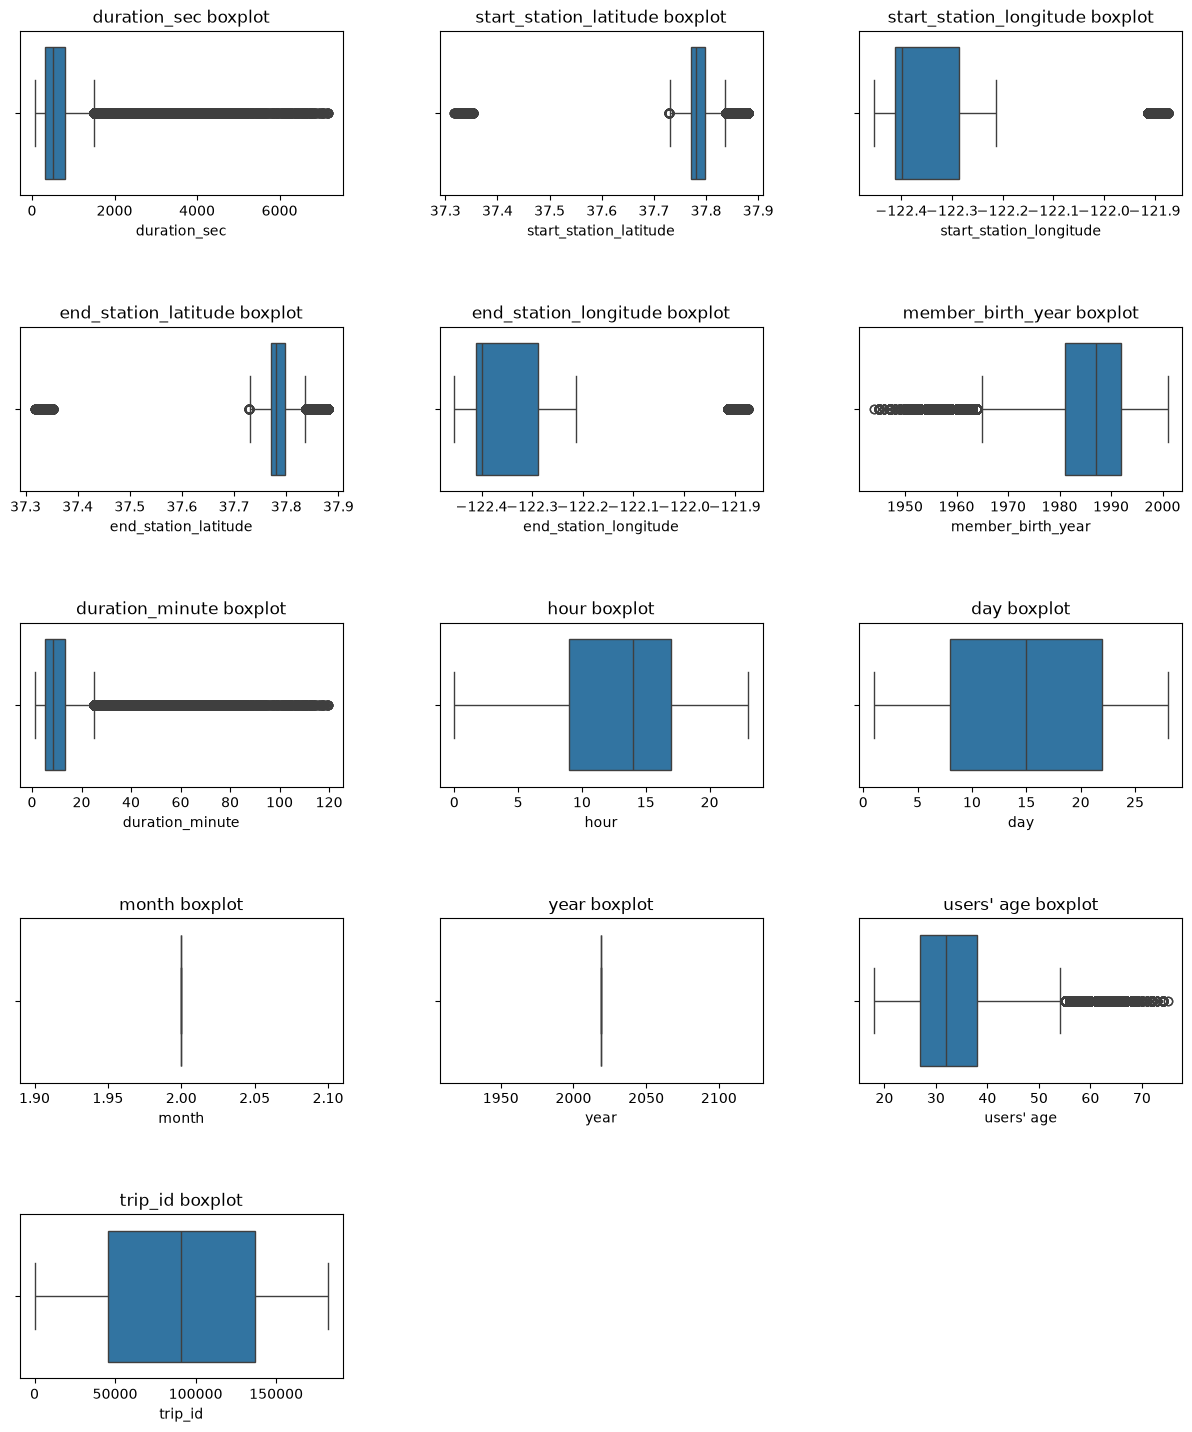

In [53]:
num_cols=df.select_dtypes('number').columns
n_cols=len(num_cols)
rows=math.ceil(n_cols/3)
plt.figure(figsize=(15,3.5*rows))
for i , col in enumerate(num_cols):
    plt.subplot(rows,3,i+1)
    sns.boxplot(df[col], orient="h")
    plt.title(f"{col} boxplot")
    plt.subplots_adjust(hspace=.8,wspace=.3)
plt.show()

In [54]:
## I will import seaborn library to support me in making visualizations 

import seaborn as sns

x=df[df["users' age"]>90]["users' age"].values
df["users' age"]=df["users' age"].replace(x,90)

y=df[df["duration_minute"]>1440]["duration_minute"].values
df["duration_minute"]=df["duration_minute"].replace(y,1440)



> ### <mark>Your analsys and exploration here </mark>


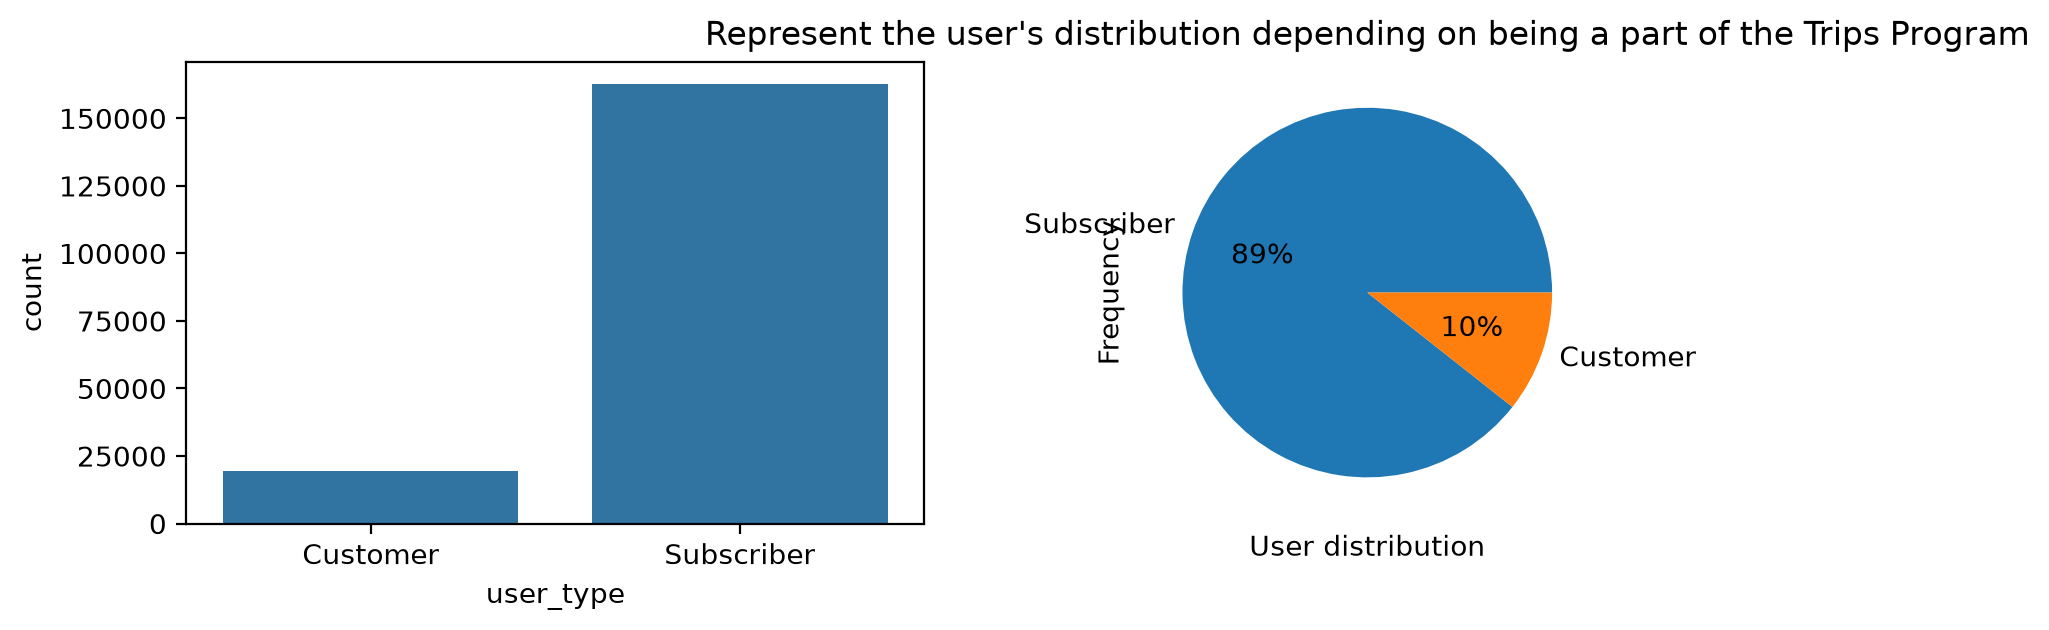

In [55]:
plt.figure(figsize = (10,3), dpi = 200)
plt.subplot(1,2,1)
sns.countplot(data=df, x='user_type')
plt.subplot(1,2,2)
unique=df["user_type"].value_counts()
count=unique.values
categories=unique.index
plt.pie(count,labels=categories, autopct="%1.1d%%")
plt.xlabel('User distribution')
plt.ylabel('Frequency')
plt.title("Represent the user's distribution depending on being a part of the Trips Program")
plt.subplots_adjust(hspace=.1,wspace=.1)
plt.show()

# <a id="2"> 2 ) What is the distribution for the bike share users on all Trips?</a>

> ### <mark>Your analsys and exploration here </mark>

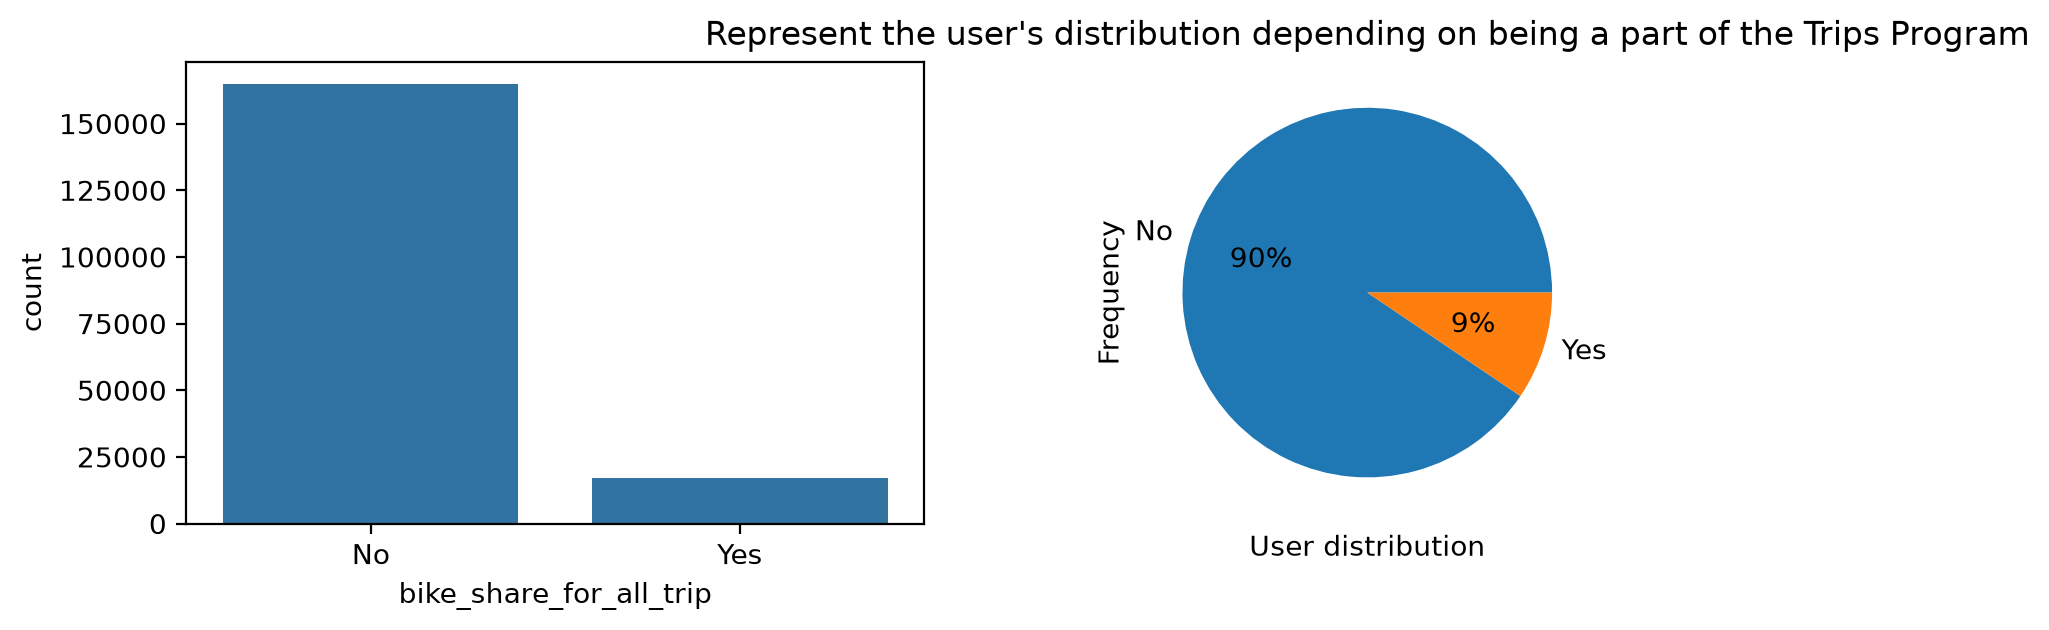

In [56]:
plt.figure(figsize = (10,3), dpi = 200)
plt.subplot(1,2,1)
sns.countplot(data=df, x='bike_share_for_all_trip')
plt.subplot(1,2,2)
unique=df["bike_share_for_all_trip"].value_counts()
count=unique.values
categories=unique.index
plt.pie(count,labels=categories, autopct="%1.1d%%")
plt.xlabel('User distribution')
plt.ylabel('Frequency')
plt.title("Represent the user's distribution depending on being a part of the Trips Program")
plt.subplots_adjust(hspace=.1,wspace=.1)
plt.show()

# <a id="3"> 3 ) What is the distribution for users' ages? </a>

> ### <mark>Your analsys and exploration here </mark>

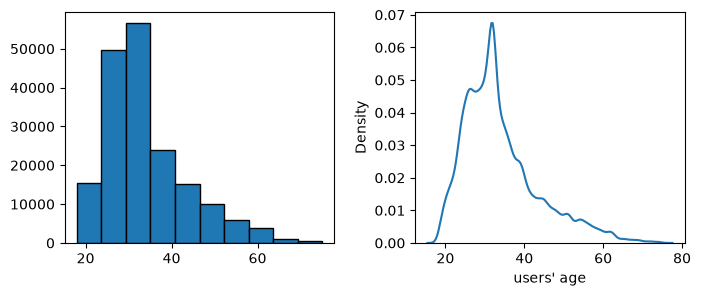

In [57]:
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.hist(df["users' age"], edgecolor="black")
plt.subplot(1,2,2)
sns.kdeplot(df["users' age"])
plt.subplots_adjust(hspace=.8,wspace=.3)
plt.show()


# <a id="4">  4 ) . Do the users' ages have outlier values?</a>


> ### <mark>Your analsys and exploration here </mark>

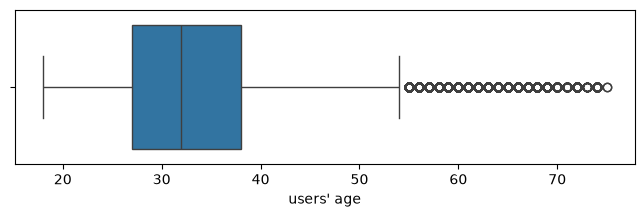

In [58]:
plt.figure(figsize=(8,2))
sns.boxplot(df["users' age"], orient="h")
plt.show()

# <a id="5">  5 ) . What is the distribution for the trip duration in minutes? </a>

In [59]:
## Review the statistic for trip duration in minutes

des=df["duration_minute"].describe()
pd.DataFrame(des.T)

,duration_minute
count,182241.000000
mean,10.795533
std,9.232620
min,1.018017
25%,5.416367
50%,8.553150
75%,13.195383
max,119.582633


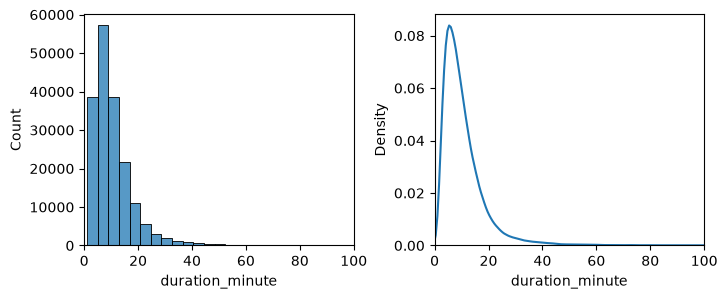

In [60]:
# Make visualization to easy get insight

plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
sns.histplot(df["duration_minute"], edgecolor="black",bins=30)
plt.xlim(0, 100)
plt.subplot(1,2,2)
sns.kdeplot(df["duration_minute"])
plt.xlim(0, 100)
plt.subplots_adjust(hspace=.8,wspace=.3)
plt.show()

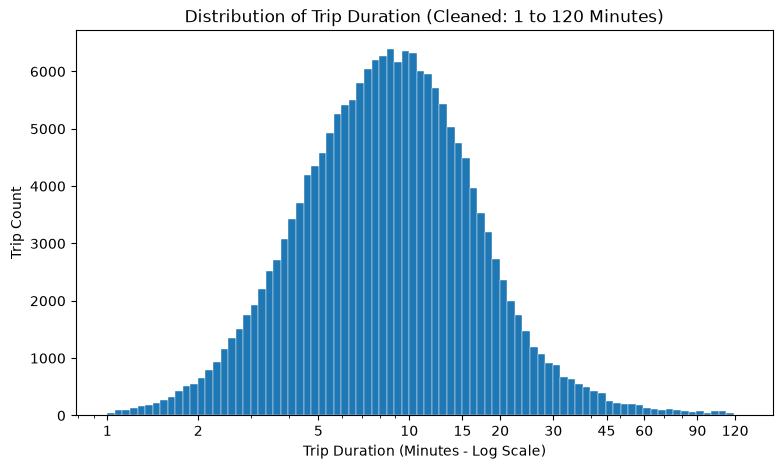

In [61]:
plt.figure(figsize=(9, 5))

bins = 10 ** np.arange(0, np.log10(120) + 0.025, 0.025)

plt.hist(
    data=df,
    x="duration_minute",
    bins=bins,
    edgecolor="white",
    linewidth=0.3,
)
plt.xscale("log")

ticks = [1, 2, 5, 10, 15, 20, 30, 45, 60, 90, 120]
plt.xticks(ticks, [str(t) for t in ticks])

plt.xlabel("Trip Duration (Minutes - Log Scale)")
plt.ylabel("Trip Count")
plt.title("Distribution of Trip Duration (Cleaned: 1 to 120 Minutes)")

plt.show()

> ### <mark>Your analsys and exploration here </mark>

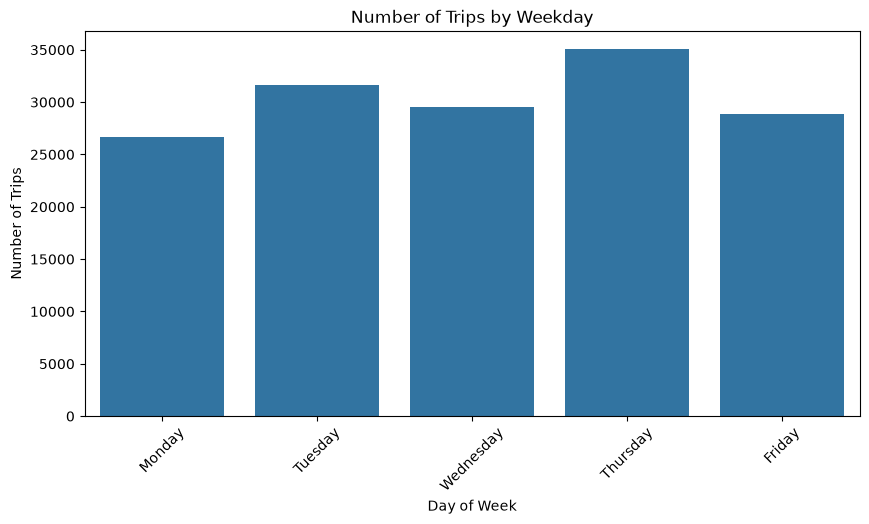

In [62]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="day_of_week",
    order=[
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
    ]
)

plt.title("Number of Trips by Weekday")
plt.xlabel("Day of Week")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)
plt.show()

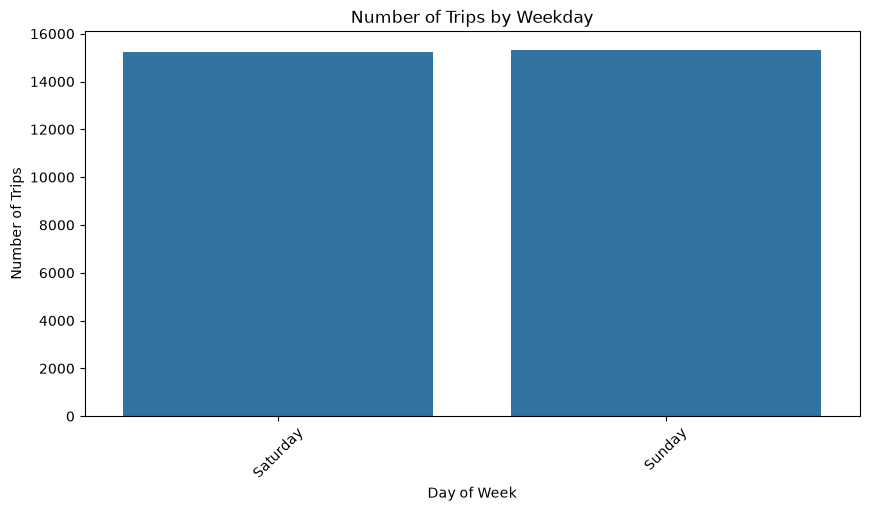

In [63]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="day_of_week",
    order=[
        "Saturday",
        "Sunday"
    ]
)

plt.title("Number of Trips by Weekday")
plt.xlabel("Day of Week")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)
plt.show()


# <a id="6"> 6 ) . What is the distribution for member_gender?</a>

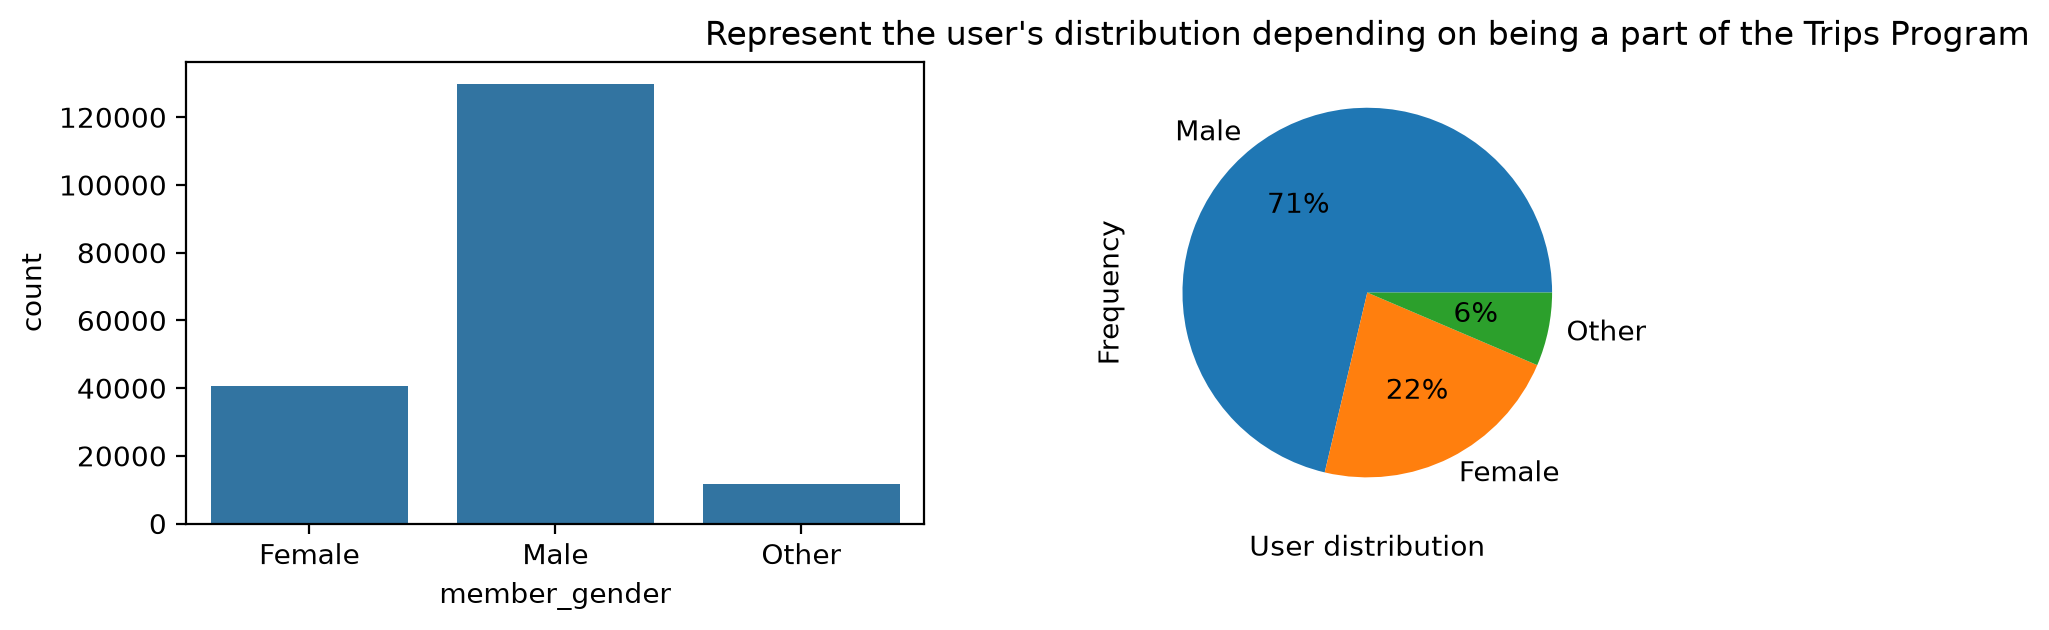

In [64]:
# Make visualization to easy get insight

plt.figure(figsize = (10,3), dpi = 200)
plt.subplot(1,2,1)
sns.countplot(data=df, x='member_gender')
plt.subplot(1,2,2)
unique=df["member_gender"].value_counts()
count=unique.values
categories=unique.index
plt.pie(count,labels=categories, autopct="%1.1d%%")
plt.xlabel('User distribution')
plt.ylabel('Frequency')
plt.title("Represent the user's distribution depending on being a part of the Trips Program")
plt.subplots_adjust(hspace=.1,wspace=.1)
plt.show()

> ### <mark>Your analsys and exploration here </mark>

# <a id="7">    7 )  . What is the distribution for the trip duration in Hours?  </a>

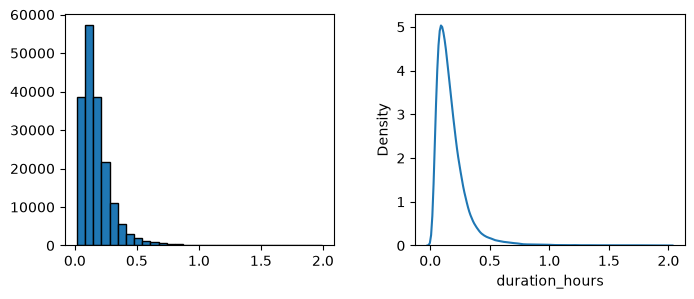

In [65]:
# Make visualization to easy get insight

plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.hist(df["duration_minute"]/60, edgecolor="black", bins=30)
plt.subplot(1,2,2)
sns.kdeplot(df["duration_minute"]/60)
plt.xlabel('duration_hours')
plt.subplots_adjust(hspace=.8,wspace=.3)
plt.show()

> ### <mark>Your analsys and exploration here </mark>

> ### <mark>Your analsys and exploration here </mark>

Key Observations from the Plot

Median Duration: Casual Customers have a notably higher median trip duration (~13 minutes) compared to Subscribers (~8 minutes).

Spread and IQR: Customer trip lengths show much greater variance (interquartile range spanning ~8 to 20 minutes), whereas 75% of all Subscriber rides finish in under 12.5 minutes.

Whisker Reach: The non-outlier range for Customers extends up to ~38 minutes, compared to ~23 minutes for Subscribers.

Analytical Takeaway

This distribution confirms distinct usage patterns between the two groups. Subscribers treat the service as a fast, reliable utility for daily commutes along direct routes. Customers use the service more leisurely and flexibly for recreation or exploration, resulting in longer and more varied trip times.

# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Bivariate Exploration</p>
# <a id="111"> Bivariate Exploration</a>

Now let's investigate relationships between pairs of variables in our data.

In [66]:
df.columns

Index(['duration_sec', 'start_time', 'end_time', 'start_station_id',
       'start_station_name', 'start_station_latitude',
       'start_station_longitude', 'end_station_id', 'end_station_name',
       'end_station_latitude', 'end_station_longitude', 'bike_id', 'user_type',
       'member_birth_year', 'member_gender', 'bike_share_for_all_trip',
       'duration_minute', 'date', 'hour', 'day', 'day_of_week', 'weekend',
       'month', 'year', 'time_id', 'users' age', 'age_group', 'trip_id'],
      dtype='str')

# <a id="8"> 8) . What the average duration of trip for the categories of user type?</a>

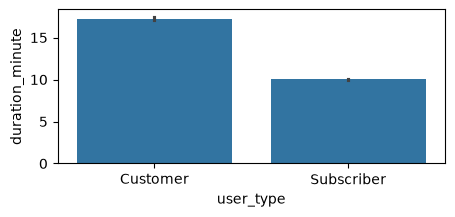

In [67]:
# Distribution of Age by user types

plt.figure(figsize=(5,2))
sns.barplot(x=df["user_type"],y=df["duration_minute"])
plt.show()

# Make visualization to easy get insight


> ### <mark>Your analsys and exploration here </mark>

# <a id="9">    9 ) . How long is the duration of the trip for each gender in minutes?  </a>

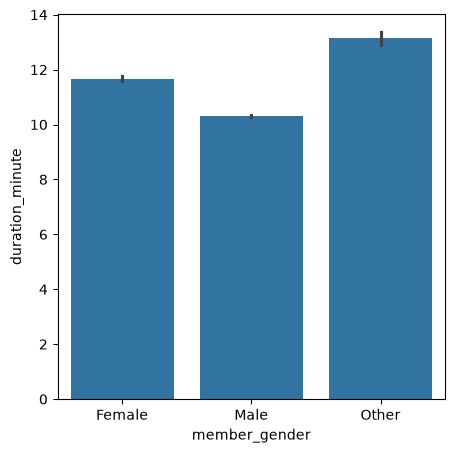

In [68]:
# Make visualization to easy get insight

# ------------------------Duration distribution by member gender

plt.figure(figsize=(5,5))
sns.barplot(x=df["member_gender"],y=df["duration_minute"])
plt.show()

# Make visualization to easy get insight


> ### <mark>Your analsys and exploration here </mark>

# <a id="10 "> 10 ) . How long is the duration of the trip for each user_type in minutes?  </a>

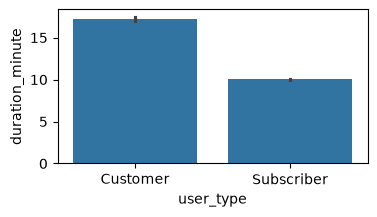

In [69]:

# Make visualization to easy get insight

plt.figure(figsize=(4,2))
sns.barplot(x=df["user_type"],y=df["duration_minute"])
plt.show()

> ### <mark>Your analsys and exploration here </mark>

# <a id="11">  11 ) . How the user distribution depending on their Age and user_type ? </a>

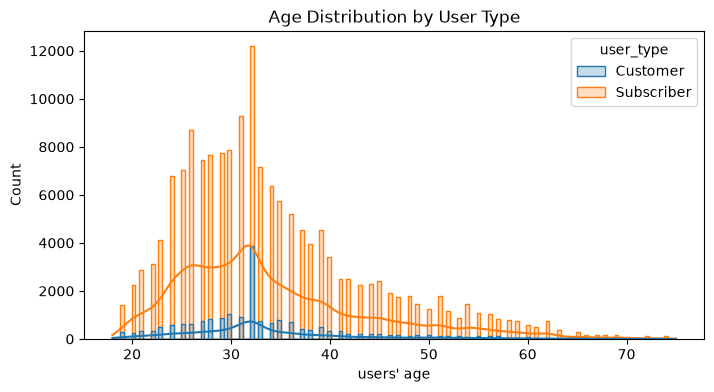

In [70]:

# Make visualization to easy get insight

plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="users' age", hue='user_type', kde=True, element="step")
plt.title("Age Distribution by User Type")
plt.show()

> ### <mark>Your analsys and exploration here </mark>

#  <a id="12"> 12 ). How the user distribution depending on their Age and member_gender ?</a>

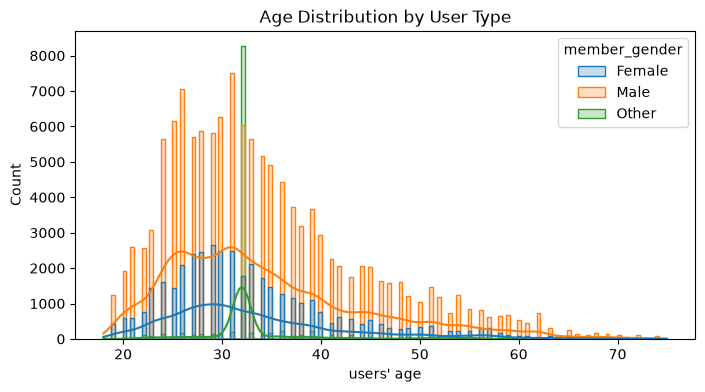

In [71]:
# Make visualization to easy get insight
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="users' age", hue='member_gender', kde=True, element="step")
plt.title("Age Distribution by User Type")
plt.show()

> ### <mark>Your analsys and exploration here </mark>


Median Age Consistency Across Genders
The median rider age is virtually identical across all reported gender identities: approximately 31 for Females, 32 for Males, and 34 for Other. This confirms that the service draws from the same core millennial and young-professional demographic regardless of gender.

Spread and Demographic Reach

Male & Other: Show slightly broader interquartile ranges (IQRs) extending into the late 30s/early 40s, with upper whiskers reaching 56-57 years. This reflects steady usage among middle-aged commuters.

Female: Leans slightly younger, with an upper whisker ending around 52 years and fewer riders in older brackets.

Senior Riders: All three defined categories show a continuous string of riders above the upper whisker reaching toward the 77-year boundary.

The "Unknown" Flat Line
The horizontal flat line at age 32 for the Unknown group is a data imputation artifact. Missing birth years in the original dataset were filled with the dataset's median age (~32), resulting in zero variance for records lacking demographic details.

### Talk about some of the relationships you observed in this part of the investigation. How did the feature(s) of interest vary with other features in the dataset?

> Trip Duration vs. User Type (Primary Driver): Trip duration varies substantially by user category. Casual Customers take significantly longer trips on average (~17.3 minutes, median ~13 minutes) than annual Subscribers (~10.1 minutes, median ~8.5 minutes). Customers also show a much wider interquartile range (8 to 20 minutes), reflecting leisure and recreational use, while Subscribers exhibit a tight distribution (5 to 12.5 minutes) consistent with time-conscious daily commuting.

> Trip Duration vs. Member Gender (Secondary Variation): Duration varies slightly across gender identities. Male riders take the shortest average trips (~10.3 minutes), Female riders average ~11.6 minutes, and riders identifying as Other average ~12.3 minutes. However, the median duration across all three groups remains steady at 8 to 9 minutes, demonstrating that the underlying commuter use case is largely uniform across genders.


### Did you observe any interesting relationships between the other features (not the main feature(s) of interest)?

> Age vs. User Type: Despite large differences in trip duration, Customers and Subscribers share an almost identical median age of ~32 years. However, Subscribers feature a noticeably wider age spread reaching up to ~57 years before outliers, indicating that annual memberships capture older, career-established daily commuters.

> Age vs. Member Gender: The age profile is exceptionally consistent across all reported genders, with medians hovering between 31 and 33 years. The service attracts the same young-professional demographic across both male and female rider groups.

> Demographic Non-Reporting and Casual Usage: The Unknown demographic category records the longest average trip duration (~13.5 minutes) and a flat imputed median age of 32. This reflects a clear relationship between ride behavior and data collection: casual single-pass riders frequently bypass profile registration, leaving demographic attributes blank while taking longer leisure rides.

# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Multivariate Exploration</p>
# <a id="1111"> Multivariate Exploration </a>

> Create plots of three or more variables to investigate your data even
further. Make sure that your investigations are justified, and follow from
your work in the previous sections.

In [72]:
## check your work 


# <a id="13">  13 ) . What is the  Correlation between each variable in the dataset?</a>

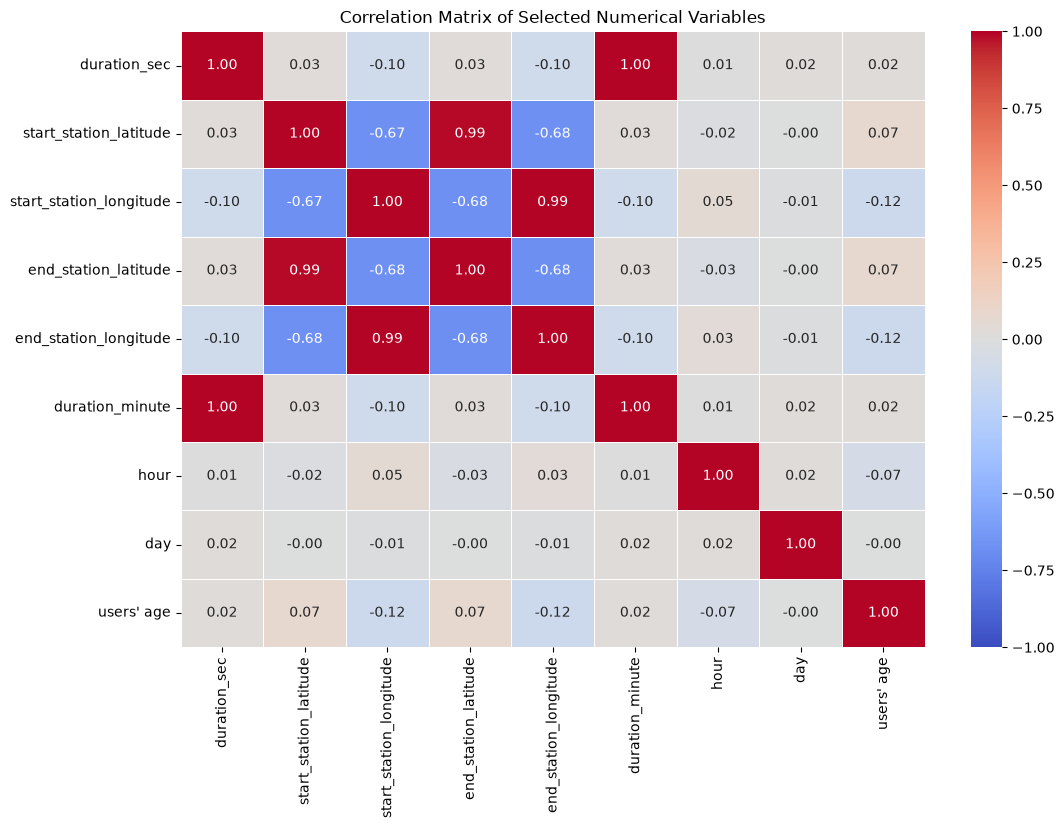

In [73]:
# Make visualization to easy get insight
cols = [
    "duration_sec",
    "start_station_latitude",
    "start_station_longitude",
    "end_station_latitude",
    "end_station_longitude",
    "duration_minute",
    "hour",
    "day",
    "users' age"
]

plt.figure(figsize=(12, 8))

sns.heatmap(
    df[cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
)

plt.title("Correlation Matrix of Selected Numerical Variables")
plt.show()



> ### <mark>Your analsys and exploration here </mark>

Example usage
- There is `no Correlation` for any variable with time ( `duration sec /minutes/hours`)



# <a id="14"> 14 )  .  What is the  Correlation between `specific numeric variables` in the dataset?</a>


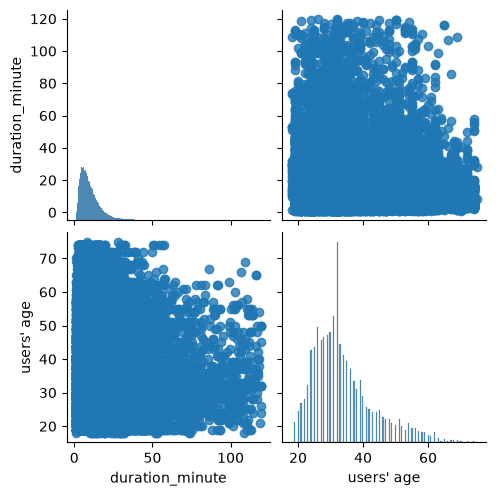

In [74]:
# Make visualization to easy get insight

selected_cols = ["duration_minute", "users' age"]
sns.pairplot(df[selected_cols], kind="reg")
plt.show()

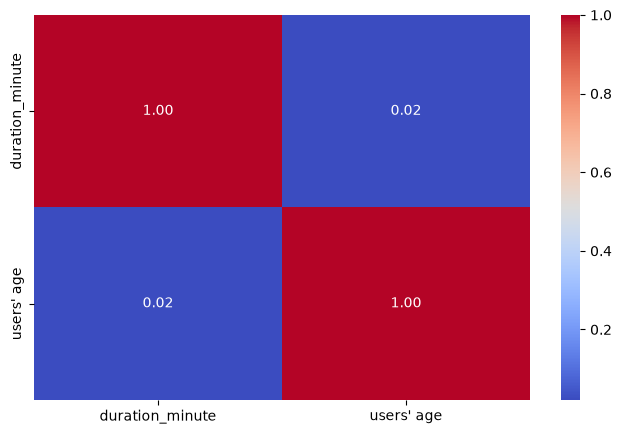

In [75]:
corr = df[["duration_minute", "users' age"]].corr()
plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True , cmap="coolwarm",fmt=".2f")
plt.show()

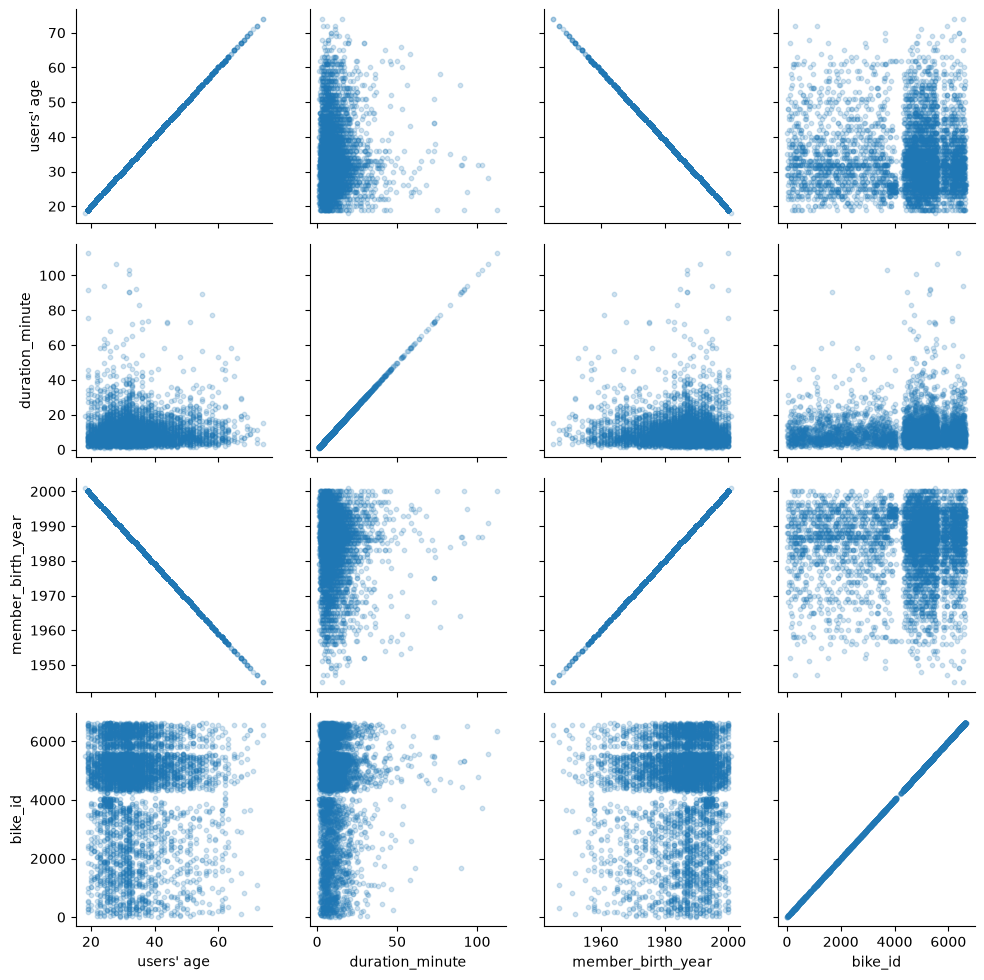

In [76]:
cols =[
    "users' age",
    "duration_minute",
    "member_birth_year",
    "bike_id",
]
g = sns.PairGrid(data=df.sample(5000, random_state=42), vars=cols)
g.map(plt.scatter, alpha=0.2, s=10)
plt.show()

> ### <mark>Your analsys and exploration here </mark>

Example usage
- There is `no Correlation` for any variable with time ( `duration sec /minutes`)




- 




- 



# <a id="15">  15 ) What is the  Correlation between data_stat variables in the dataset?</a>


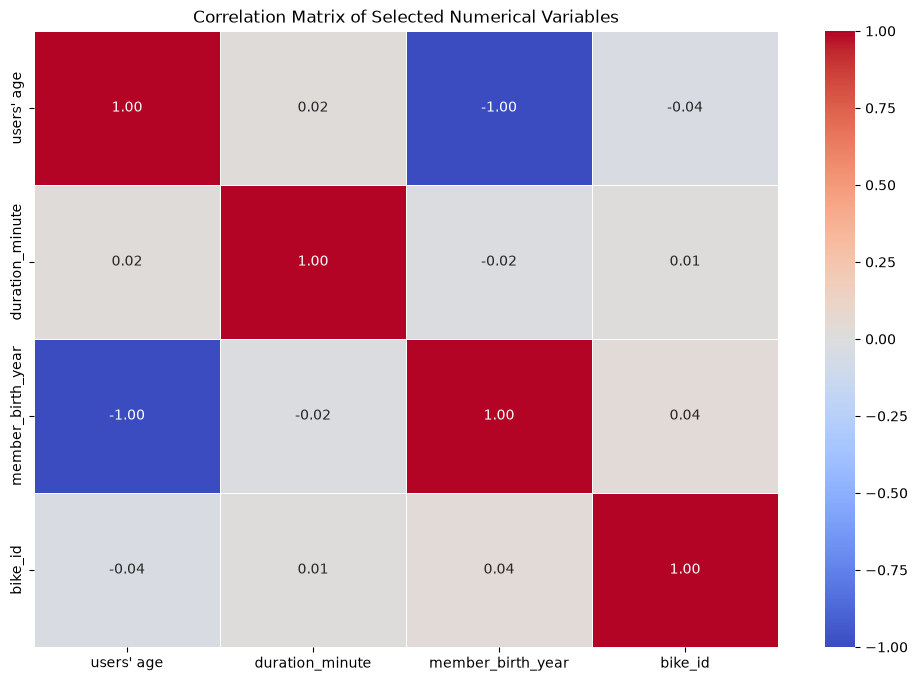

In [77]:
cols =[
    "users' age",
    "duration_minute",
    "member_birth_year",
    "bike_id",
]
plt.figure(figsize=(12, 8))

sns.heatmap(
    df[cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
)

plt.title("Correlation Matrix of Selected Numerical Variables")
plt.show()

> ### <mark>The above charts show how Correlation between specific numeric variables in the dataset using heatmap plots  </mark>



**Actually the `heat map`  display the above ideas in clear percentages**



- There is `no Correlation` for any variable with time ( `duration sec /minutes`)




- There is a `negative  Correlation` between  member_birth_year  and age which normal.




- There is `no significant Correlation` for any variable with `bike_id `


# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Conclusions</p>
# <a id="1100"> Conclusions </a>

#example
- Most users were Male (around 74%) and the majority were annual Subscribers (around 90%), primarily concentrated between 25 and 40 years old.


- User type is the main driver of trip behavior: Subscribers take short, consistent commute rides (median around 8.5 minutes), while casual Customers take longer, more variable leisure trips (median around 13 minutes).


- Trip duration is independent of rider age (correlation r = 0.02); riders across all age groups take trips of similar lengths, typically under 15 minutes.


- Start and end station coordinates correlate almost perfectly (r = 0.99), showing that trips are localized within specific neighborhoods and commercial hubs.




## limitation 
example
- Significant demographic data was missing for birth year and gender (especially among casual customers), and filling missing values with the median created an artificial spike at age 32.

- The dataset only covers a single month (February 2019), which does not account for seasonal variations, summer tourism, or weather changes across the year.

- The dataset lacks route and trajectory tracking, providing only start and end stations rather than actual distance traveled or elevation gain.

- Outliers with extreme trip durations (docking errors or overnight rentals) skewed the raw data, requiring filtering to analyze realistic riding behavior.
